# Chapter 4 — Regression and Prediction

## Learning Objectives

This notebook covers simple and multiple linear regression, least squares, fitted values, residuals, RMSE, cross-validation, factor variables, interactions, diagnostics, prediction intervals, and nonlinear extensions.

## Theoretical Explanation

Regression models the relationship between predictors and a numeric response. In simple linear regression, the model fits a line. In multiple regression, the model estimates a linear relationship with several predictors. Least squares chooses coefficients that minimize the sum of squared residuals.

For data science, regression is often used for prediction rather than only explanation. Therefore, out-of-sample performance, residual behavior, extrapolation risk, and model complexity matter. RMSE measures prediction error, while residual plots help detect nonlinearity, heteroskedasticity, and influential points.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Simple Linear Regression

Intercept: 11.279
Slope: 4.694
RMSE: 6.125
R2: 0.837


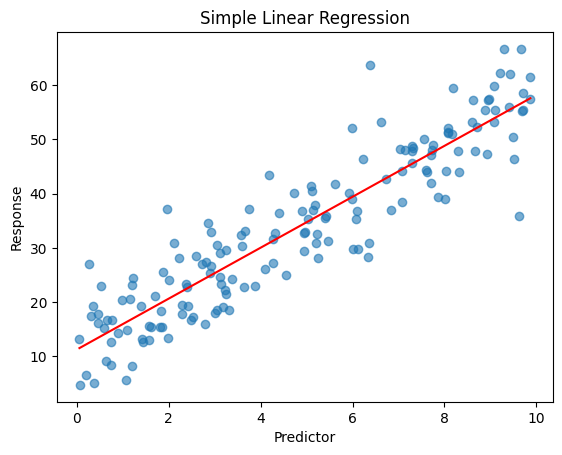

In [2]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

rng = np.random.RandomState(RANDOM_STATE)
x = rng.uniform(0, 10, 160)
y = 12 + 4.5*x + rng.normal(0, 6, size=len(x))
X = x.reshape(-1, 1)
model = LinearRegression().fit(X, y)
fitted = model.predict(X)
residuals = y - fitted
print('Intercept:', round(model.intercept_, 3))
print('Slope:', round(model.coef_[0], 3))
print('RMSE:', round(mean_squared_error(y, fitted, squared=False), 3))
print('R2:', round(r2_score(y, fitted), 3))
plt.scatter(x, y, alpha=0.6)
plt.plot(np.sort(x), model.predict(np.sort(x).reshape(-1,1)), color='red')
plt.title('Simple Linear Regression')
plt.xlabel('Predictor')
plt.ylabel('Response')
plt.show()

### Output Interpretation

The slope estimates the expected change in the response for one unit increase in the predictor. RMSE measures typical prediction error in response units.

## 2. Residual Diagnostics

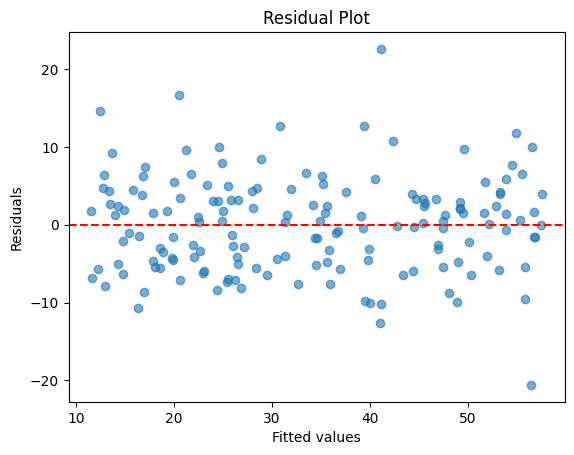

Residual mean: 0.0


In [3]:
plt.scatter(fitted, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()
print('Residual mean:', round(residuals.mean(), 6))

### Output Interpretation

Residuals should be centered around zero. Clear patterns in residuals may indicate missing nonlinear terms, heteroskedasticity, or model misspecification.

## 3. Multiple Regression with Categorical Variable

In [4]:
df = pd.DataFrame({
    'size': rng.normal(1500, 350, 300),
    'age': rng.uniform(0, 40, 300),
    'area': rng.choice(['A', 'B', 'C'], 300)
})
df['price'] = 50000 + 180*df['size'] - 1200*df['age'] + df['area'].map({'A': 0, 'B': 30000, 'C': -20000}) + rng.normal(0, 25000, 300)
X = pd.get_dummies(df[['size', 'age', 'area']], drop_first=True)
y = df['price']
reg = LinearRegression().fit(X, y)
print(pd.Series(reg.coef_, index=X.columns).round(2))
print('Intercept:', round(reg.intercept_, 2))
print('Training RMSE:', round(mean_squared_error(y, reg.predict(X), squared=False), 2))

size        180.15
age       -1170.42
area_B    28562.74
area_C   -19844.91
dtype: float64


Intercept: 51126.85
Training RMSE: 25495.69


### Output Interpretation

Dummy variables represent categorical effects relative to a reference category. Coefficients estimate the contribution of each predictor while holding other predictors constant.

## 4. Cross-Validation and Polynomial Regression

In [5]:
poly = make_pipeline(PolynomialFeatures(degree=3), Ridge(alpha=1.0))
cv_rmse = -cross_val_score(poly, X[['size']], y, scoring='neg_root_mean_squared_error', cv=5)
print('5-fold CV RMSE values:', np.round(cv_rmse, 2))
print('Mean CV RMSE:', round(cv_rmse.mean(), 2))

5-fold CV RMSE values: [30847.65 40947.91 28454.38 40269.07 37782.03]
Mean CV RMSE: 35660.21


### Output Interpretation

Cross-validation estimates out-of-sample performance. It helps avoid overinterpreting in-sample metrics that may look overly optimistic.

## Extended Study Notes

The most important professional habit in practical statistics is interpretation. A statistic is not useful only because it can be computed; it is useful when it answers a real question about data quality, uncertainty, relationships, prediction, or decision-making. In data science work, the same numerical result can have different meanings depending on the sampling process, the metric used, the business cost of errors, and the assumptions behind the procedure.

This notebook intentionally uses original, simplified examples instead of copying the book examples verbatim. The purpose is academic understanding: connect the statistical concept to a runnable Python workflow, inspect the output, and explain what the output means. This also supports academic integrity because the notebook demonstrates the learned concept in original wording and with adapted code.

## Chapter Summary

This chapter was reproduced as a compact but complete study notebook. It combines conceptual explanation, Python implementation, output interpretation, and practical data science context.

## Key Takeaways

- Statistical concepts should be connected to data science decisions, not treated as isolated formulas.
- Visual summaries and resampling methods often provide practical intuition beyond formula-based statistics.
- Model evaluation must consider uncertainty, bias, sampling, and the cost of incorrect conclusions.
- The output of code should always be interpreted in context before making decisions.